In [ ]:
!pip install ultralytics  -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

BASE_FOLDER = "/content/drive/MyDrive/CarParts"
os.makedirs(BASE_FOLDER, exist_ok=True)

print(f"Folder creado: {BASE_FOLDER}")

Folder creado: /content/drive/MyDrive/CarParts


In [ ]:
import torch

In [ ]:
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

GPU: Tesla T4
VRAM (GB): 15.637086208


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolo11m-seg.pt")

In [ ]:
results = model.train(
    data="carparts-seg.yaml",
    #carparts-seg.yaml
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=25,
    project=BASE_FOLDER,
    name="anatomist_yolo11m_seg",
    save=True,
    plots=True,
    exist_ok=True
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=carparts-seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=anatomist_yolo11m_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [ ]:
metrics = model.val()
print(metrics)

In [ ]:
metrics_test = model.val(split="test")
print(metrics_test)


image 1/1 /content/datasets/carparts-seg/images/test/train358_jpg.rf.ec8de2045d728dea2c1896ebaa63b462.jpg: 640x640 1 back_left_door, 1 back_left_light, 1 back_right_door, 1 front_bumper, 1 front_glass, 1 front_left_door, 1 front_left_light, 1 hood, 1 left_mirror, 1 wheel, 50.2ms
Speed: 2.5ms preprocess, 50.2ms inference, 17.6ms postprocess per image at shape (1, 3, 640, 640)
Objetos detectados: 10


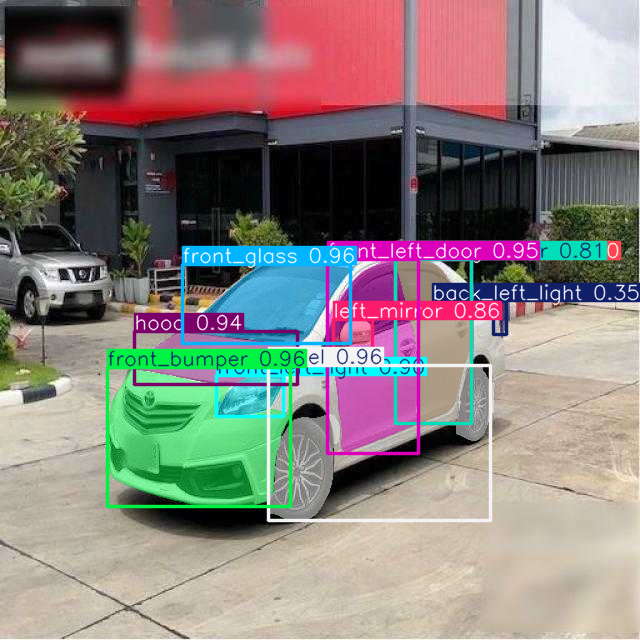

In [ ]:
image_path = "datasets/carparts-seg/images/test/"

import os
test_images = os.listdir(image_path)

img = image_path + test_images[0]

results = model(img, conf=0.25, iou=0.5)

boxes = results[0].boxes
num_objects = len(boxes)

print(f"Objetos detectados: {num_objects}")

results[0].show()


In [ ]:
import os
import glob
import json
import torch

In [ ]:
from ultralytics import YOLO
from PIL import Image
from google.colab.patches import cv2_imshow

In [ ]:
model_path =  "/content/drive/MyDrive/CarParts/anatomist_yolo11m_seg/weights/best.pt"
model = YOLO(model_path)

In [ ]:
test_image_dir = '/content/test_imgs/'
image_extensions = ['*.jpg', '*.jpeg', '*.png']

In [ ]:
image_files = []

for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(test_image_dir, ext)))

In [ ]:
all_results_data = []

In [ ]:
print(f"--- Starting Inference on {len(image_files)} images ---")
for img_path in image_files:
    # Run inference
    # conf=0.25 is standard, adjust if you want more/fewer detections
    results = model.predict(source=img_path, conf=0.25, iou=0.6, imgsz=768)

    result = results[0]
    num_objects = len(result.boxes)
    filename = os.path.basename(img_path)

    # Display Image with Bounding Boxes
    print(f"\nFile: {filename} | Detected Objects: {num_objects}")
    annotated_img = result.plot() # Returns a numpy array (BGR)

    # Convert BGR to RGB for correct display
    display_img = Image.fromarray(annotated_img[..., ::-1])
    display(display_img)

    # Prepare JSON data for this image
    image_json = {
        "filename": filename,
        "object_count": num_objects,
        "detections": []
    }

    # Extract box coordinates and confidence
    for box in result.boxes:
        image_json["detections"].append({
            "class_id": int(box.cls[0]),
            "label": "Object",
            "confidence": float(box.conf[0]),
            "bbox_xyxy": box.xyxy[0].tolist() # [xmin, ymin, xmax, ymax]
        })

    all_results_data.append(image_json)



In [ ]:
#  Print and Save JSON Output
final_json = json.dumps(all_results_data, indent=4)
print("\n--- Final Inference JSON Report ---")
#print(final_json)

In [ ]:
print(f"--- Starting Export to ONNX (Opset 18) ---")
success = model.export(
    format='onnx',
    opset=18,
    simplify=True,
    imgsz=640
)

--- Starting Export to ONNX (Opset 18) ---
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/drive/MyDrive/CarParts/anatomist_yolo11m_seg/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 59, 8400), (1, 32, 160, 160)) (43.1 MB)

ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.0s, saved as '/content/drive/MyDrive/CarParts/anatomist_yolo11m_seg/weights/best.onnx' (85.6 MB)

Export complete (8.5s)
Results saved to /content/drive/MyDrive/CarParts/anatomist_yolo11m_seg/weights/best.onnx
Predict:         yolo predict task=segment model=/content/drive/MyDrive/CarParts/anatomist_yolo11m_seg/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=/content/drive/MyDrive/CarParts/anatomist_yolo11m_seg/weights/best.onnx imgsz=640 data=/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/datasets/carparts-seg.yam